<a href="https://colab.research.google.com/github/ARehman007-max/internship/blob/main/task15_Model_Tuning_%26_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Lab: Hyperparameter Tuning with Neural Networks
# Dataset: Wine classification (3 classes, 13 features)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load and prepare the Wine dataset
wine = load_wine()
X, y = wine.data, wine.target

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features (important for neural networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Classes: {wine.target_names}")

Training set shape: (142, 13)
Test set shape: (36, 13)
Classes: ['class_0' 'class_1' 'class_2']


In [3]:
def create_baseline_model(learning_rate=0.001):
    """Create a simple neural network with default settings"""
    model = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Train baseline model
baseline_model = create_baseline_model()
baseline_history = baseline_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Evaluate baseline
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f"Baseline Test Accuracy: {baseline_test_acc:.4f}")
print(f"Baseline Test Loss: {baseline_test_loss:.4f}")

Baseline Test Accuracy: 0.9444
Baseline Test Loss: 0.0884


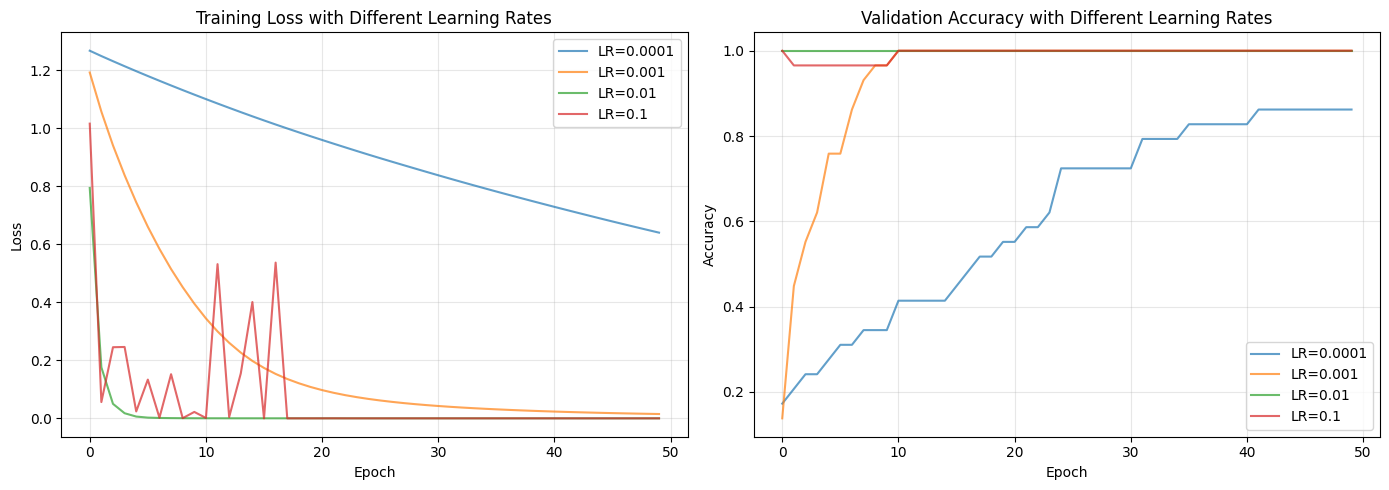

LR=0.0001: Final validation accuracy = 0.8621
LR=0.001: Final validation accuracy = 1.0000
LR=0.01: Final validation accuracy = 1.0000
LR=0.1: Final validation accuracy = 1.0000


In [4]:
def experiment_learning_rate():
    """Compare different learning rates"""
    learning_rates = [0.0001, 0.001, 0.01, 0.1]
    histories = {}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for lr in learning_rates:
        model = create_baseline_model(learning_rate=lr)
        history = model.fit(
            X_train, y_train,
            epochs=50,
            batch_size=32,
            validation_split=0.2,
            verbose=0
        )
        histories[lr] = history

        # Plot training loss
        axes[0].plot(history.history['loss'], label=f'LR={lr}', alpha=0.7)
        axes[1].plot(history.history['val_accuracy'], label=f'LR={lr}', alpha=0.7)

    axes[0].set_title('Training Loss with Different Learning Rates')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Validation Accuracy with Different Learning Rates')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print final accuracies
    for lr, history in histories.items():
        print(f"LR={lr}: Final validation accuracy = {history.history['val_accuracy'][-1]:.4f}")

experiment_learning_rate()

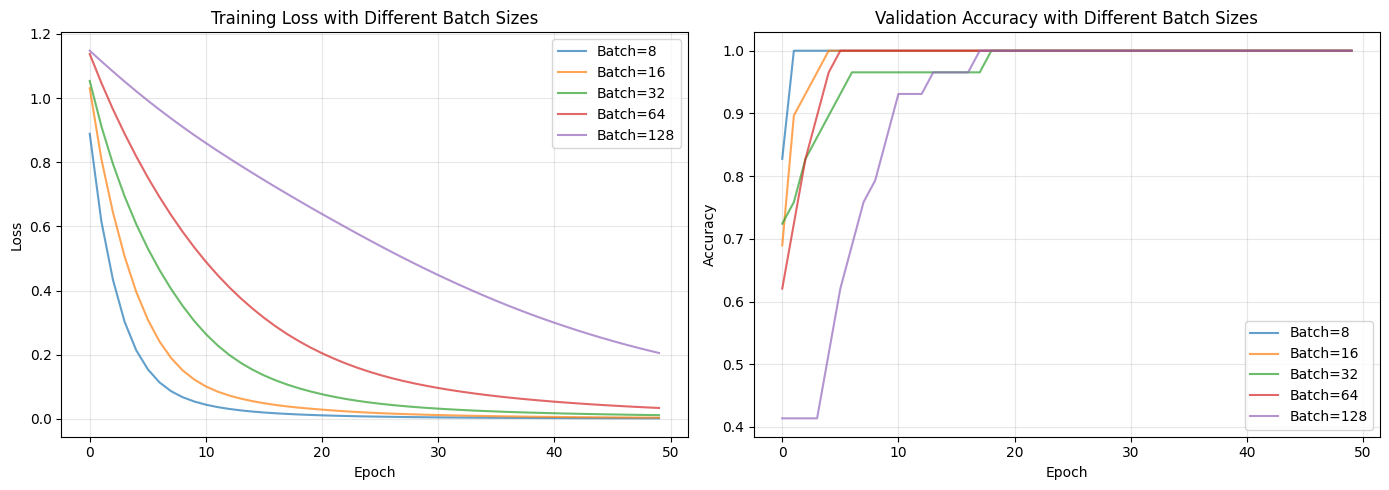


Batch Size Results:
--------------------------------------------------
Batch=  8: Test accuracy = 0.9444, Training time = 50 epochs
Batch= 16: Test accuracy = 0.9722, Training time = 50 epochs
Batch= 32: Test accuracy = 1.0000, Training time = 50 epochs
Batch= 64: Test accuracy = 0.9444, Training time = 50 epochs
Batch=128: Test accuracy = 0.9722, Training time = 50 epochs


In [5]:
def experiment_batch_size():
    """Compare different batch sizes"""
    batch_sizes = [8, 16, 32, 64, 128]
    results = {}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for batch_size in batch_sizes:
        model = create_baseline_model()
        history = model.fit(
            X_train, y_train,
            epochs=50,
            batch_size=batch_size,
            validation_split=0.2,
            verbose=0
        )

        results[batch_size] = {
            'history': history,
            'test_loss': None,
            'test_acc': None
        }

        # Evaluate on test set
        test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
        results[batch_size]['test_loss'] = test_loss
        results[batch_size]['test_acc'] = test_acc

        # Plot
        axes[0].plot(history.history['loss'], label=f'Batch={batch_size}', alpha=0.7)
        axes[1].plot(history.history['val_accuracy'], label=f'Batch={batch_size}', alpha=0.7)

    axes[0].set_title('Training Loss with Different Batch Sizes')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Validation Accuracy with Different Batch Sizes')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print results
    print("\nBatch Size Results:")
    print("-" * 50)
    for bs, res in results.items():
        print(f"Batch={bs:3d}: Test accuracy = {res['test_acc']:.4f}, "
              f"Training time = {len(res['history'].history['loss'])} epochs")

    return results

batch_results = experiment_batch_size()

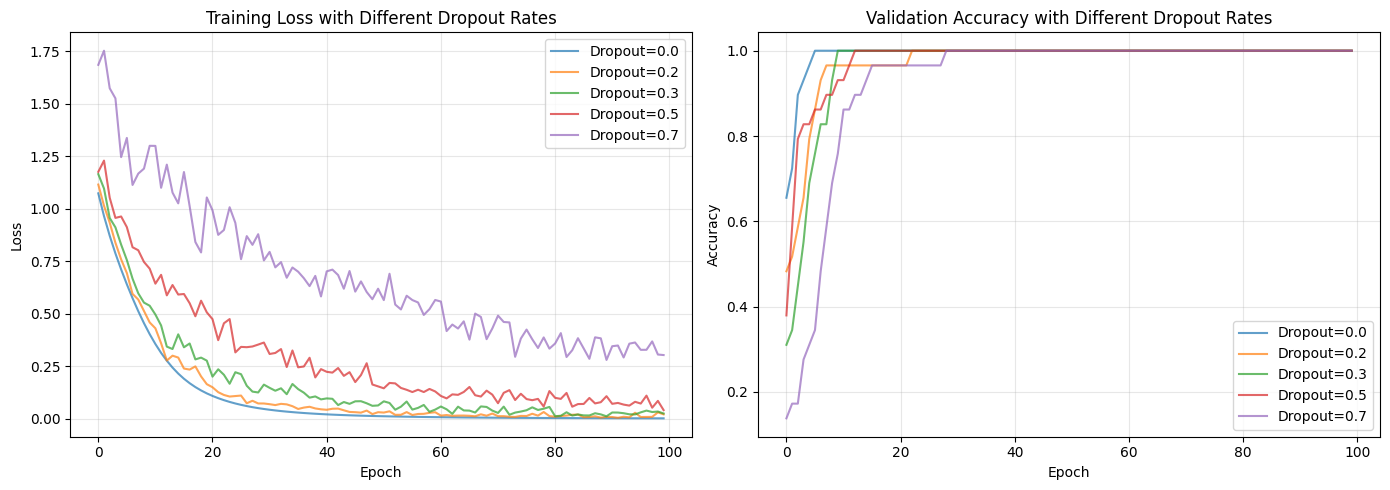


Dropout Rate Results:
--------------------------------------------------
Dropout=0.0: Test accuracy = 0.9167, Val accuracy = 1.0000
Dropout=0.2: Test accuracy = 0.9722, Val accuracy = 1.0000
Dropout=0.3: Test accuracy = 0.9722, Val accuracy = 1.0000
Dropout=0.5: Test accuracy = 0.9722, Val accuracy = 1.0000
Dropout=0.7: Test accuracy = 0.9722, Val accuracy = 1.0000


In [6]:
def create_dropout_model(dropout_rate=0.5):
    """Create model with dropout layers"""
    model = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def experiment_dropout():
    """Compare different dropout rates"""
    dropout_rates = [0.0, 0.2, 0.3, 0.5, 0.7]
    results = {}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for dropout_rate in dropout_rates:
        model = create_dropout_model(dropout_rate)
        history = model.fit(
            X_train, y_train,
            epochs=100,
            batch_size=32,
            validation_split=0.2,
            verbose=0
        )

        test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
        results[dropout_rate] = {
            'test_acc': test_acc,
            'test_loss': test_loss,
            'val_acc': history.history['val_accuracy'][-1]
        }

        # Plot
        axes[0].plot(history.history['loss'], label=f'Dropout={dropout_rate}', alpha=0.7)
        axes[1].plot(history.history['val_accuracy'], label=f'Dropout={dropout_rate}', alpha=0.7)

    axes[0].set_title('Training Loss with Different Dropout Rates')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Validation Accuracy with Different Dropout Rates')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print results
    print("\nDropout Rate Results:")
    print("-" * 50)
    for dr, res in results.items():
        print(f"Dropout={dr}: Test accuracy = {res['test_acc']:.4f}, "
              f"Val accuracy = {res['val_acc']:.4f}")

    return results

dropout_results = experiment_dropout()

In [7]:
def create_l2_model(l2_lambda=0.001):
    """Create model with L2 regularization"""
    model = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(64, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.Dense(32, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def experiment_l2():
    """Compare different L2 regularization strengths"""
    l2_values = [0.0, 0.0001, 0.001, 0.01, 0.1]
    results = {}

    for l2_lambda in l2_values:
        model = create_l2_model(l2_lambda)
        history = model.fit(
            X_train, y_train,
            epochs=100,
            batch_size=32,
            validation_split=0.2,
            verbose=0
        )

        test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
        results[l2_lambda] = {
            'test_acc': test_acc,
            'test_loss': test_loss,
            'val_acc': history.history['val_accuracy'][-1]
        }

        print(f"L2={l2_lambda}: Test accuracy = {test_acc:.4f}, "
              f"Val accuracy = {history.history['val_accuracy'][-1]:.4f}")

    return results

l2_results = experiment_l2()

L2=0.0: Test accuracy = 0.9722, Val accuracy = 1.0000
L2=0.0001: Test accuracy = 0.9722, Val accuracy = 1.0000
L2=0.001: Test accuracy = 0.9722, Val accuracy = 1.0000
L2=0.01: Test accuracy = 0.9444, Val accuracy = 1.0000
L2=0.1: Test accuracy = 1.0000, Val accuracy = 1.0000


Epoch 1/200
1/4 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.2188 - loss: 1.6251
Epoch 1: val_loss improved from None to 1.20042, saving model to best_wine_model.keras

Epoch 1: finished saving model to best_wine_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.2655 - loss: 1.4821 - val_accuracy: 0.3103 - val_loss: 1.2004 - learning_rate: 0.0010
Epoch 2/200
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2812 - loss: 1.2939
Epoch 2: val_loss improved from 1.20042 to 1.10873, saving model to best_wine_model.keras

Epoch 2: finished saving model to best_wine_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3186 - loss: 1.2614 - val_accuracy: 0.3793 - val_loss: 1.1087 - learning_rate: 0.0010
Epoch 3/200
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3125 - loss: 1.3239
Epoch 3: val_loss improved from 1.10873 to 1.01868, saving model to best_wine_model.keras

Epoch 3: finished saving model to best_wine_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/ste

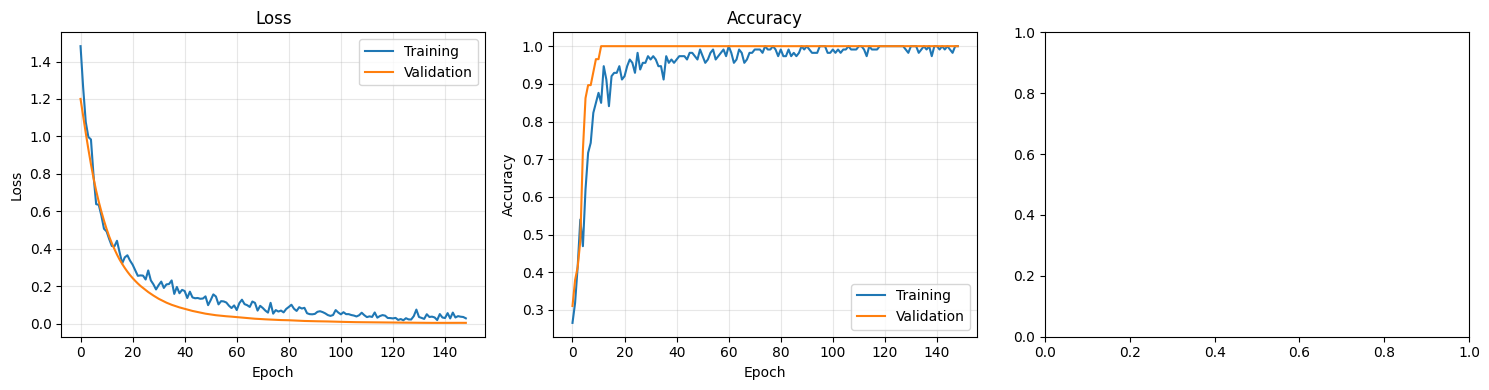


Optimized Model Test Accuracy: 0.9722
Optimized Model Test Loss: 0.0644
Training stopped after 149 epochs


In [8]:
def create_optimized_model():
    """Create model with Batch Normalization"""
    model = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        layers.Dense(32),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def train_with_callbacks():
    """Train model with early stopping, learning rate scheduling, and checkpointing"""

    # Create callbacks
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    lr_scheduler = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )

    checkpoint = ModelCheckpoint(
        'best_wine_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )

    # Create and train model
    model = create_optimized_model()

    history = model.fit(
        X_train, y_train,
        epochs=200,  # Set high; early stopping will halt training
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop, lr_scheduler, checkpoint],
        verbose=1
    )

    # Plot training history
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(history.history['loss'], label='Training')
    axes[0].plot(history.history['val_loss'], label='Validation')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['accuracy'], label='Training')
    axes[1].plot(history.history['val_accuracy'], label='Validation')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    if 'lr' in history.history:
        axes[2].plot(history.history['lr'])
        axes[2].set_title('Learning Rate')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Learning Rate')
        axes[2].set_yscale('log')
        axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Evaluate
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nOptimized Model Test Accuracy: {test_acc:.4f}")
    print(f"Optimized Model Test Loss: {test_loss:.4f}")
    print(f"Training stopped after {len(history.history['loss'])} epochs")

    return model, history

optimized_model, optimized_history = train_with_callbacks()

In [9]:
def grid_search_hyperparameters():
    """Perform a simple grid search over key hyperparameters"""

    # Define hyperparameter grid
    param_grid = {
        'learning_rate': [0.0005, 0.001, 0.005],
        'batch_size': [16, 32, 64],
        'dropout_rate': [0.2, 0.3, 0.5],
        'neurons': [32, 64]
    }

    results = []

    # Test a subset of combinations (not all for time)
    for lr in param_grid['learning_rate']:
        for batch_size in param_grid['batch_size']:
            for dropout in [0.3]:  # Keep dropout fixed to reduce combinations
                for neurons in param_grid['neurons']:

                    # Create model
                    model = keras.Sequential([
                        layers.Input(shape=(13,)),
                        layers.Dense(neurons, activation='relu'),
                        layers.Dropout(dropout),
                        layers.Dense(neurons//2, activation='relu'),
                        layers.Dense(3, activation='softmax')
                    ])

                    model.compile(
                        optimizer=Adam(learning_rate=lr),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy']
                    )

                    # Train with early stopping
                    early_stop = EarlyStopping(
                        monitor='val_loss',
                        patience=10,
                        restore_best_weights=True,
                        verbose=0
                    )

                    history = model.fit(
                        X_train, y_train,
                        epochs=100,
                        batch_size=batch_size,
                        validation_split=0.2,
                        callbacks=[early_stop],
                        verbose=0
                    )

                    # Evaluate
                    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

                    results.append({
                        'lr': lr,
                        'batch_size': batch_size,
                        'dropout': dropout,
                        'neurons': neurons,
                        'test_acc': test_acc,
                        'val_acc': history.history['val_accuracy'][-1],
                        'epochs': len(history.history['loss'])
                    })

                    print(f"LR={lr}, Batch={batch_size}, Dropout={dropout}, "
                          f"Neurons={neurons}: Test acc = {test_acc:.4f}")

    # Find best configuration
    best_result = max(results, key=lambda x: x['test_acc'])

    print("\n" + "="*60)
    print("BEST CONFIGURATION FOUND:")
    print(f"Learning Rate: {best_result['lr']}")
    print(f"Batch Size: {best_result['batch_size']}")
    print(f"Dropout Rate: {best_result['dropout']}")
    print(f"Neurons: {best_result['neurons']}")
    print(f"Test Accuracy: {best_result['test_acc']:.4f}")
    print(f"Validation Accuracy: {best_result['val_acc']:.4f}")
    print(f"Training Epochs: {best_result['epochs']}")

    return results, best_result

search_results, best_config = grid_search_hyperparameters()

LR=0.0005, Batch=16, Dropout=0.3, Neurons=32: Test acc = 0.9722
LR=0.0005, Batch=16, Dropout=0.3, Neurons=64: Test acc = 0.9722
LR=0.0005, Batch=32, Dropout=0.3, Neurons=32: Test acc = 0.9722
LR=0.0005, Batch=32, Dropout=0.3, Neurons=64: Test acc = 1.0000
LR=0.0005, Batch=64, Dropout=0.3, Neurons=32: Test acc = 0.9722
LR=0.0005, Batch=64, Dropout=0.3, Neurons=64: Test acc = 1.0000
LR=0.001, Batch=16, Dropout=0.3, Neurons=32: Test acc = 0.9722
LR=0.001, Batch=16, Dropout=0.3, Neurons=64: Test acc = 0.9444
LR=0.001, Batch=32, Dropout=0.3, Neurons=32: Test acc = 0.9722
LR=0.001, Batch=32, Dropout=0.3, Neurons=64: Test acc = 0.9444
LR=0.001, Batch=64, Dropout=0.3, Neurons=32: Test acc = 1.0000
LR=0.001, Batch=64, Dropout=0.3, Neurons=64: Test acc = 0.9722
LR=0.005, Batch=16, Dropout=0.3, Neurons=32: Test acc = 1.0000
LR=0.005, Batch=16, Dropout=0.3, Neurons=64: Test acc = 0.9722
LR=0.005, Batch=32, Dropout=0.3, Neurons=32: Test acc = 0.9444
LR=0.005, Batch=32, Dropout=0.3, Neurons=64: Test

Epoch 1/200
1/4 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5000 - loss: 1.5378
Epoch 1: val_loss improved from None to 1.02116, saving model to final_wine_model.keras

Epoch 1: finished saving model to final_wine_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.4602 - loss: 1.4445 - val_accuracy: 0.4138 - val_loss: 1.0212 - learning_rate: 0.0010
Epoch 2/200
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4688 - loss: 1.2411
Epoch 2: val_loss improved from 1.02116 to 0.94131, saving model to final_wine_model.keras

Epoch 2: finished saving model to final_wine_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4779 - loss: 1.1576 - val_accuracy: 0.5517 - val_loss: 0.9413 - learning_rate: 0.0010
Epoch 3/200
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5312 - loss: 1.0628
Epoch 3: val_loss improved from 0.94131 to 0.87110, saving model to final_wine_model.keras

Epoch 3: finished saving model to final_wine_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30

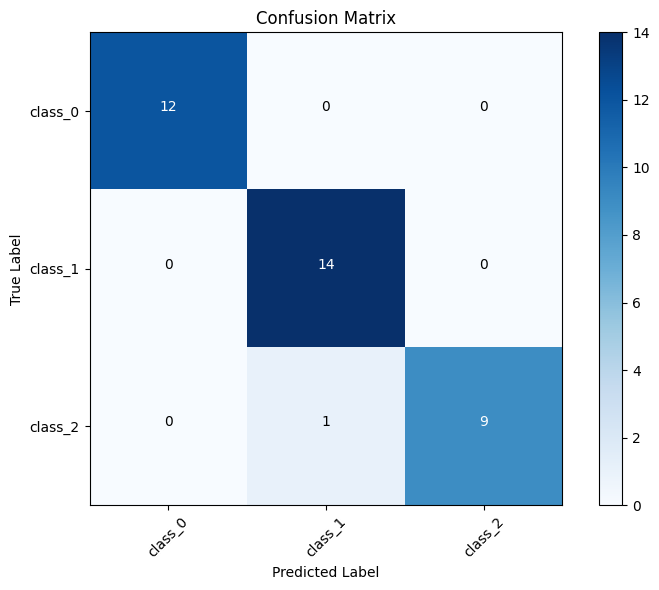

In [10]:
def create_final_model(config):
    """Create and train the final model with the best configuration"""

    model = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(config['neurons'], activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(config['dropout']),
        layers.Dense(config['neurons']//2, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(config['dropout']),
        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=config['lr']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )

    lr_scheduler = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )

    checkpoint = ModelCheckpoint(
        'final_wine_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )

    # Train
    history = model.fit(
        X_train, y_train,
        epochs=200,
        batch_size=config['batch_size'],
        validation_split=0.2,
        callbacks=[early_stop, lr_scheduler, checkpoint],
        verbose=1
    )

    return model, history

# Use best configuration from search (or define manually)
best_manual_config = {
    'lr': 0.001,
    'batch_size': 32,
    'dropout': 0.3,
    'neurons': 64
}

final_model, final_history = create_final_model(best_manual_config)

# Final evaluation
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Model Performance:")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Make predictions
y_pred = final_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=wine.target_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(wine.target_names))
plt.xticks(tick_marks, wine.target_names, rotation=45)
plt.yticks(tick_marks, wine.target_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add text annotations
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

In [11]:
print("""
LAB SUMMARY: Hyperparameter Tuning for Neural Networks

Key Takeaways:
1. Learning Rate: Most important hyperparameter - too high causes instability, too low causes slow training
2. Batch Size: Smaller batches (8-32) generalize better but train slower; larger batches (128+) are faster but may generalize worse
3. Regularization: Dropout (0.2-0.5) and L2 (0.0001-0.01) help prevent overfitting
4. Early Stopping: Automatically prevents overfitting by monitoring validation loss
5. Learning Rate Scheduling: ReduceLROnPlateau dynamically adjusts learning rate during training
6. Batch Normalization: Stabilizes training and allows higher learning rates
7. Grid Search: Systematic exploration of hyperparameter combinations

Practical Tips:
- Start with reasonable defaults (Adam lr=0.001, batch_size=32, dropout=0.3)
- Use early stopping to avoid guessing number of epochs
- Monitor both training and validation curves for signs of overfitting
- Consider the trade-off between model complexity and training time
- Use callbacks to automate hyperparameter tuning
""")


LAB SUMMARY: Hyperparameter Tuning for Neural Networks

Key Takeaways:
1. Learning Rate: Most important hyperparameter - too high causes instability, too low causes slow training
2. Batch Size: Smaller batches (8-32) generalize better but train slower; larger batches (128+) are faster but may generalize worse
3. Regularization: Dropout (0.2-0.5) and L2 (0.0001-0.01) help prevent overfitting
4. Early Stopping: Automatically prevents overfitting by monitoring validation loss
5. Learning Rate Scheduling: ReduceLROnPlateau dynamically adjusts learning rate during training
6. Batch Normalization: Stabilizes training and allows higher learning rates
7. Grid Search: Systematic exploration of hyperparameter combinations

Practical Tips:
- Start with reasonable defaults (Adam lr=0.001, batch_size=32, dropout=0.3)
- Use early stopping to avoid guessing number of epochs
- Monitor both training and validation curves for signs of overfitting
- Consider the trade-off between model complexity and tr